Итак, что у нас есть?  

В постановке задачи сказано, что нам предоставлена **выборка** $X_1, X_2, ... , X_n$ из некоторого непрерывного распределения.   

То есть у нас есть упорядоченное множество одинаково распределенных непрерывных независимых случайных величин.

In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Для удобства я переименую свой файл, используя латинские символы.  

И посмотрю вообще на размеры файла, с которым предстоит работать.

In [19]:
source = Path("Levashov_Maksim.xlsx")

df = pd.read_excel(source)

df.shape

(1000000, 2)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Unnamed: 0  1000000 non-null  int64  
 1   Выборка     1000000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 15.3 MB


In [21]:
df.describe()

,Unnamed: 0,Выборка
count,1000000.000000,1000000.000000
mean,499999.500000,1.297595
std,288675.278932,1.296622
min,0.000000,0.000001
25%,249999.750000,0.374431
50%,499999.500000,0.899025
75%,749999.250000,1.798831
max,999999.000000,16.510099


Максимальное значение, которое принимает случайная величина из нашей выбоки - это $\approx$ 16, а минимальная - практически около 0.  Воспользуемся этой информацией, когда будем строить эмпирическую функцию распределния.

А пкоа построим гистограмму выборки. Для этого нам будет достаточно встроенного метода hist с параметром bins = "fd" ("Freedman-Diaconis")

Text(0.5, 1.0, 'Гистограмма распределения')

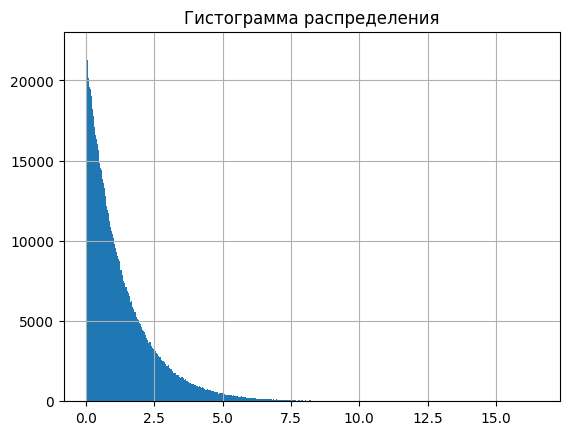

In [22]:
sample = df["Выборка"]
sample.hist(bins="fd")
plt.title("Гистограмма распределения")

И нормализуем значения через параметр Density.

Text(0.5, 1.0, 'Гистограмма распределения (нормализованная)')

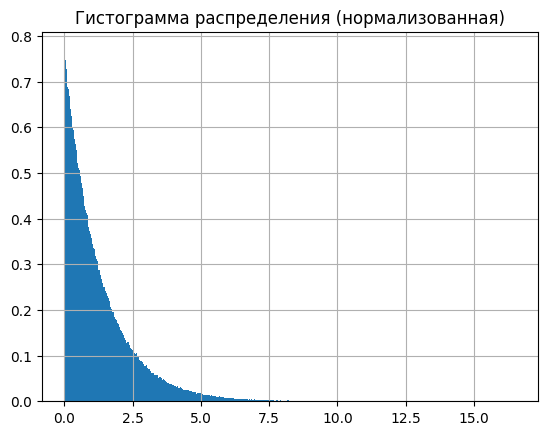

In [23]:
sample = df["Выборка"]
sample.hist(bins="fd", density=True)
plt.title("Гистограмма распределения (нормализованная)")

Вспомним, что такое эмпирическая функция распределения:  
$$F^{*}_n(y) = \frac{1}{n} \sum_{i = 1}^{n} \mathbb{I}(X_i < y)$$
где $$\mathbb{I}(X_i < y) = \begin{cases} 1, если \ X_i < y \\ 0, иначе \end{cases}$$

In [24]:
def I(x, y):
    return int((x < y))

In [25]:
def F(sample: np.ndarray, y) -> float:
    n = len(sample)
    indicators_list = [I(x, y) for x in sample]
    return (1/n) * sum(indicators_list)

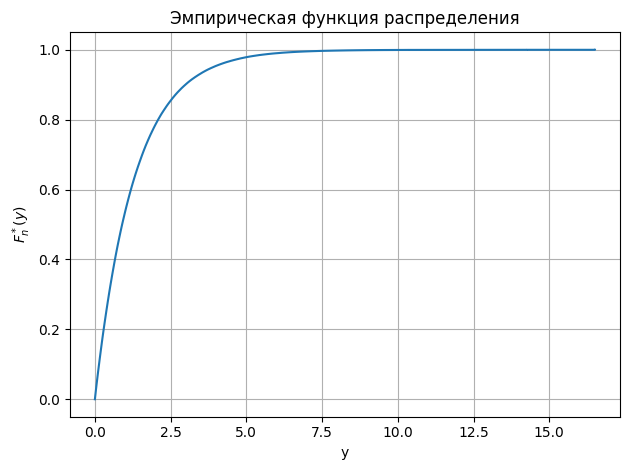

In [26]:
sample_sorted = np.sort(sample)
n = len(sample_sorted)
y_values = np.arange(0, n) / n

plt.step(sample_sorted, y_values, where="post")
plt.title("Эмпирическая функция распределения")
plt.xlabel(rf"y")
plt.ylabel(rf"$F^{'*'}_n(y)$")
plt.grid()
plt.tight_layout()
plt.show()

Выведем оба графика одновременно.

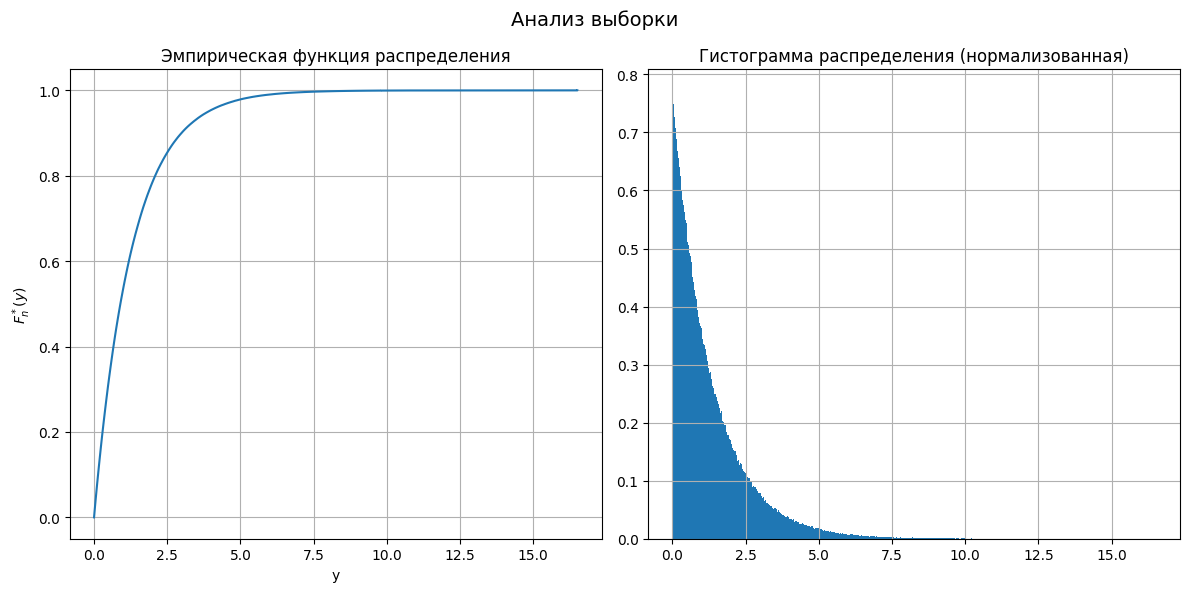

In [27]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes = axes.flatten()

fig.suptitle("Анализ выборки", fontsize=14)

sample_sorted = np.sort(sample)
n = len(sample_sorted)
y_values = np.arange(0, n) / n

axes[0].step(sample_sorted, y_values, where="post")
axes[0].set_title("Эмпирическая функция распределения")
axes[0].set_xlabel(rf"y")
axes[0].set_ylabel(rf"$F^{'*'}_n(y)$")
axes[0].grid()

sample = df["Выборка"]
axes[1].hist(sample, bins="fd", density=True)
axes[1].set_title("Гистограмма распределения (нормализованная)")
axes[1].grid()
axes[0].set_xlabel(rf"y")

plt.tight_layout()
plt.show()

Внешне наша ЭФР и гистограмма очень сильно напоминают экспоненциальное распределение.  

Посмотрите сами: говорим, что $\xi \sim E_{\lambda}, \lambda > 0$, если $$f(t) = \begin{cases} \lambda \cdot e^{-\lambda \cdot t}, t > 0 \\ 0, иначе \end{cases}$$

И $$F_{\xi}(t) = \begin{cases} 0, t \leq 0 \\ 1 - e^{-\lambda \cdot t} = 1 - \frac{1}{e^{\lambda \cdot t}}, t > 0 \end{cases}$$

Соответственно (давайте посмотрим на график ЭФР) - в точке **0** у нас значение **0**, а затем мы отнимаем от единицы **много**, после чего, двигаясь по числовой прямой, отнимаем все **меньше**, **приближаясь к единице.**. Именно это  
 нам и говорит запись $1 - e^{-\lambda \cdot t}, t > 0$.  

 С плотностью можно провести аналогичные "наивные" рассуждения.

Вроде бы опредилились, что имеем дело с экспоненциальным распределением, но с каким же параметром? Давайте подумаем:  

Известно, что для экспоненциального распределения верно: $\mathbb{E}(X) = \frac{1}{\lambda}$.  
Так как мы работаем с выборкой $\Longrightarrow \overline{X} = \frac{1}{n} \sum X_i \Longrightarrow \overline{X} \approx \mathbb{E}(X) = \frac{1}{\lambda} \Longrightarrow \lambda = \frac{1}{\overline{X}}$

Давайте проверим это, построив поверх наших графиков аналогичные графики для экспоненциального распределения. (с параметром $\lambda = \frac{1}{\overline{X}}$

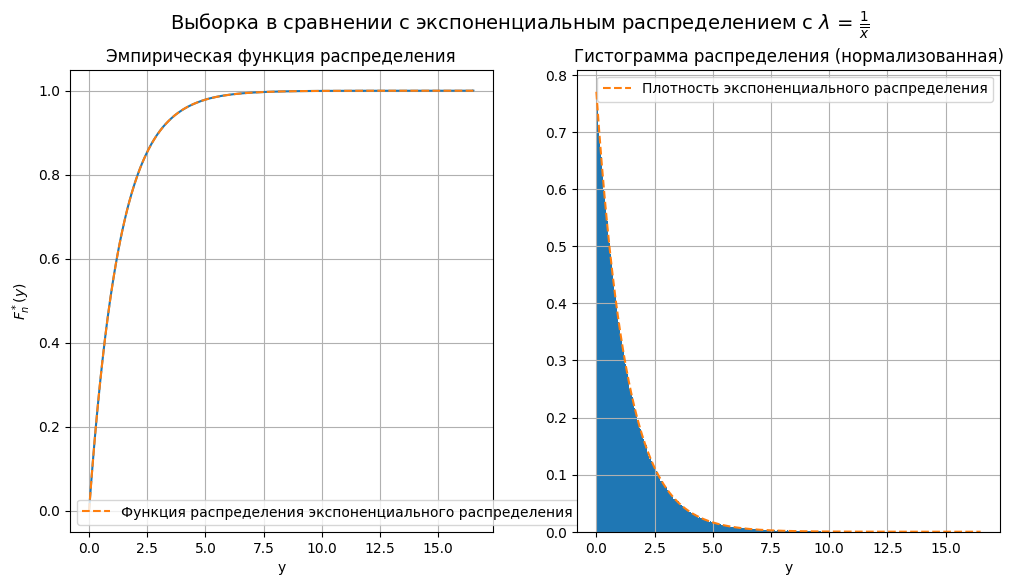

In [ ]:
from scipy.stats import expon


loc, scale = expon.fit(sample, floc=0)

lambda_hat = 1 / scale

x = np.linspace(0, max(sample), 1000)

pdf = expon.pdf(x, loc=loc, scale=scale)
cdf = expon.cdf(x, loc=loc, scale=scale)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes = axes.flatten()

fig.suptitle(r"Выборка в сравнении с экспоненциальным распределением с $\lambda$ = $\frac{1}{\overline{x}}$", fontsize=14)

sample_sorted = np.sort(sample)
n = len(sample_sorted)
y_values = np.arange(0, n) / n

axes[0].step(sample_sorted, y_values, where="post")
axes[0].set_title("Эмпирическая функция распределения")
axes[0].set_xlabel(rf"y")
axes[0].set_ylabel(rf"$F^{'*'}_n(y)$")
axes[0].grid()

axes[0].plot(x, cdf, label = "Функция распределения экспоненциального распределения", linestyle="--")
axes[0].legend()

sample = df["Выборка"]
axes[1].hist(sample, bins="fd", density=True)
axes[1].set_title("Гистограмма распределения (нормализованная)")
axes[1].grid()
axes[1].set_xlabel(rf"y")

axes[1].plot(x, pdf, label = "Плотность экспоненциального распределения", linestyle="--")
axes[1].legend()

plt.subplots_adjust()
plt.show()

Видим, что и плотность и распределение экспоненциального распределения совпадают с ЭФР и гистограммой нашей выборки. Полагаем, в таком случае, что наша выборка имеет экспоненциальное распределение с параметром $\lambda = \frac{1}{\overline{X}}$